# Redis Environment Dataset

## Exploratory Data Analysis

### Import libraries

In [206]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import LogNorm
import seaborn as sns

from pathlib import Path

### Loading the data

In [207]:
df = pd.read_csv("redis_gym_observation.csv")

In [208]:
df.head()

,date,redis-leader_num_pods,redis-leader_desired_replicas,redis-leader_cpu_usage,redis-leader_mem_usage,redis-leader_traffic_in,redis-leader_traffic_out,redis-leader_latency,redis-follower_num_pods,redis-follower_desired_replicas,redis-follower_cpu_usage,redis-follower_mem_usage,redis-follower_traffic_in,redis-follower_traffic_out,redis-follower_latency
0,2022-09-10 05:40:37,1,2,372,0.0,633,3914,0.03,1,1,73,6.7,225,48,0.03
1,2022-09-10 05:40:38,1,2,372,0.0,633,3914,0.03,1,1,73,6.7,225,48,0.03
2,2022-09-10 05:40:38,1,2,372,0.0,633,3914,0.03,1,1,73,6.7,225,48,0.03
3,2022-09-10 05:40:38,1,2,372,0.0,633,3914,0.03,1,1,73,6.7,225,48,0.03
4,2022-09-10 05:40:38,1,2,372,0.0,633,3914,0.03,1,1,73,6.7,225,48,0.03


### Schema, dtypes, missing values

2 services × 7 metrics + the `date` column = 15 columns total.

In [209]:
print(f"Dataset shape: {df.shape}")
print(f"Dataset columns names and types:")
df.info()

Dataset shape: (100000, 15)
Dataset columns names and types:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   date                             100000 non-null  str    
 1   redis-leader_num_pods            100000 non-null  int64  
 2   redis-leader_desired_replicas    100000 non-null  int64  
 3   redis-leader_cpu_usage           100000 non-null  int64  
 4   redis-leader_mem_usage           100000 non-null  float64
 5   redis-leader_traffic_in          100000 non-null  int64  
 6   redis-leader_traffic_out         100000 non-null  int64  
 7   redis-leader_latency             100000 non-null  float64
 8   redis-follower_num_pods          100000 non-null  int64  
 9   redis-follower_desired_replicas  100000 non-null  int64  
 10  redis-follower_cpu_usage         100000 non-null  int64  
 11  redis-follower_m

In [210]:
# Convert date to datetime objects
df["date"] = pd.to_datetime(df["date"])
df_time = df.set_index("date")

print(f"Data spans from {df_time.index.min()} to {df_time.index.max()}")
print(f"Duration: {(df_time.index.max() - df_time.index.min()).total_seconds() / 3600:.1f} hours")

Data spans from 2022-09-10 05:40:37 to 2022-09-12 01:33:21
Duration: 43.9 hours


In [211]:
print("Missing values:")
df.isna().sum()

Missing values:


date                               0
redis-leader_num_pods              0
redis-leader_desired_replicas      0
redis-leader_cpu_usage             0
redis-leader_mem_usage             0
redis-leader_traffic_in            0
redis-leader_traffic_out           0
redis-leader_latency               0
redis-follower_num_pods            0
redis-follower_desired_replicas    0
redis-follower_cpu_usage           0
redis-follower_mem_usage           0
redis-follower_traffic_in          0
redis-follower_traffic_out         0
redis-follower_latency             0
dtype: int64

In [212]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,100000,2022-09-11 02:32:44.502000,2022-09-10 05:40:37,2022-09-10 10:49:31.750000,2022-09-11 00:46:05,2022-09-11 18:18:30.250000,2022-09-12 01:33:21,NaN
redis-leader_num_pods,100000.0,4.94202,1.0,4.0,5.0,6.0,8.0,1.281372
redis-leader_desired_replicas,100000.0,3.36487,1.0,3.0,3.0,4.0,6.0,0.770302
redis-leader_cpu_usage,100000.0,568.74527,3.0,470.0,525.0,702.0,1184.0,174.985662
redis-leader_mem_usage,100000.0,8.96018,0.0,0.7,2.3,16.4,41.0,8.900301
redis-leader_traffic_in,100000.0,700.30125,0.0,561.0,605.0,859.0,2377.0,282.635047
redis-leader_traffic_out,100000.0,3812.83872,0.0,2962.0,3294.0,4694.0,11109.0,1524.375453
redis-leader_latency,100000.0,12305.271162,0.0,0.017,0.019,0.021,9004164.74,295589.249872
redis-follower_num_pods,100000.0,2.3437,1.0,1.0,1.0,4.0,8.0,1.873079
redis-follower_desired_replicas,100000.0,1.09536,1.0,1.0,1.0,1.0,4.0,0.314845


### Duplicates

Prometheus scrapes the cluster at a fixed interval but the underlying system state changes at a different (usually lower) rate. This means many consecutive scrapes record the exact same metric values at different timestamps. Quantifying this is critical, because feeding the agent thousands of identical states with no transition tells it nothing useful and biases the experience distribution heavily.

In [213]:
columns_to_check = df.columns.drop("date")
exact_dups = df.duplicated().sum()
value_dups = df.duplicated(subset=columns_to_check).sum()

print(f"Exact-row duplicates: {exact_dups}")
print(f"Value duplicates (ignoring date): {value_dups}")
print(f"Value-duplicate fraction: {value_dups / len(df):.2%}")

Exact-row duplicates: 14756
Value duplicates (ignoring date): 61177
Value-duplicate fraction: 61.18%


In [214]:
df.nunique()

date                               79505
redis-leader_num_pods                  8
redis-leader_desired_replicas          6
redis-leader_cpu_usage               954
redis-leader_mem_usage               358
redis-leader_traffic_in             1114
redis-leader_traffic_out            4118
redis-leader_latency                 675
redis-follower_num_pods                8
redis-follower_desired_replicas        4
redis-follower_cpu_usage             330
redis-follower_mem_usage             702
redis-follower_traffic_in            598
redis-follower_traffic_out           170
redis-follower_latency               675
dtype: int64

### Data Distributions

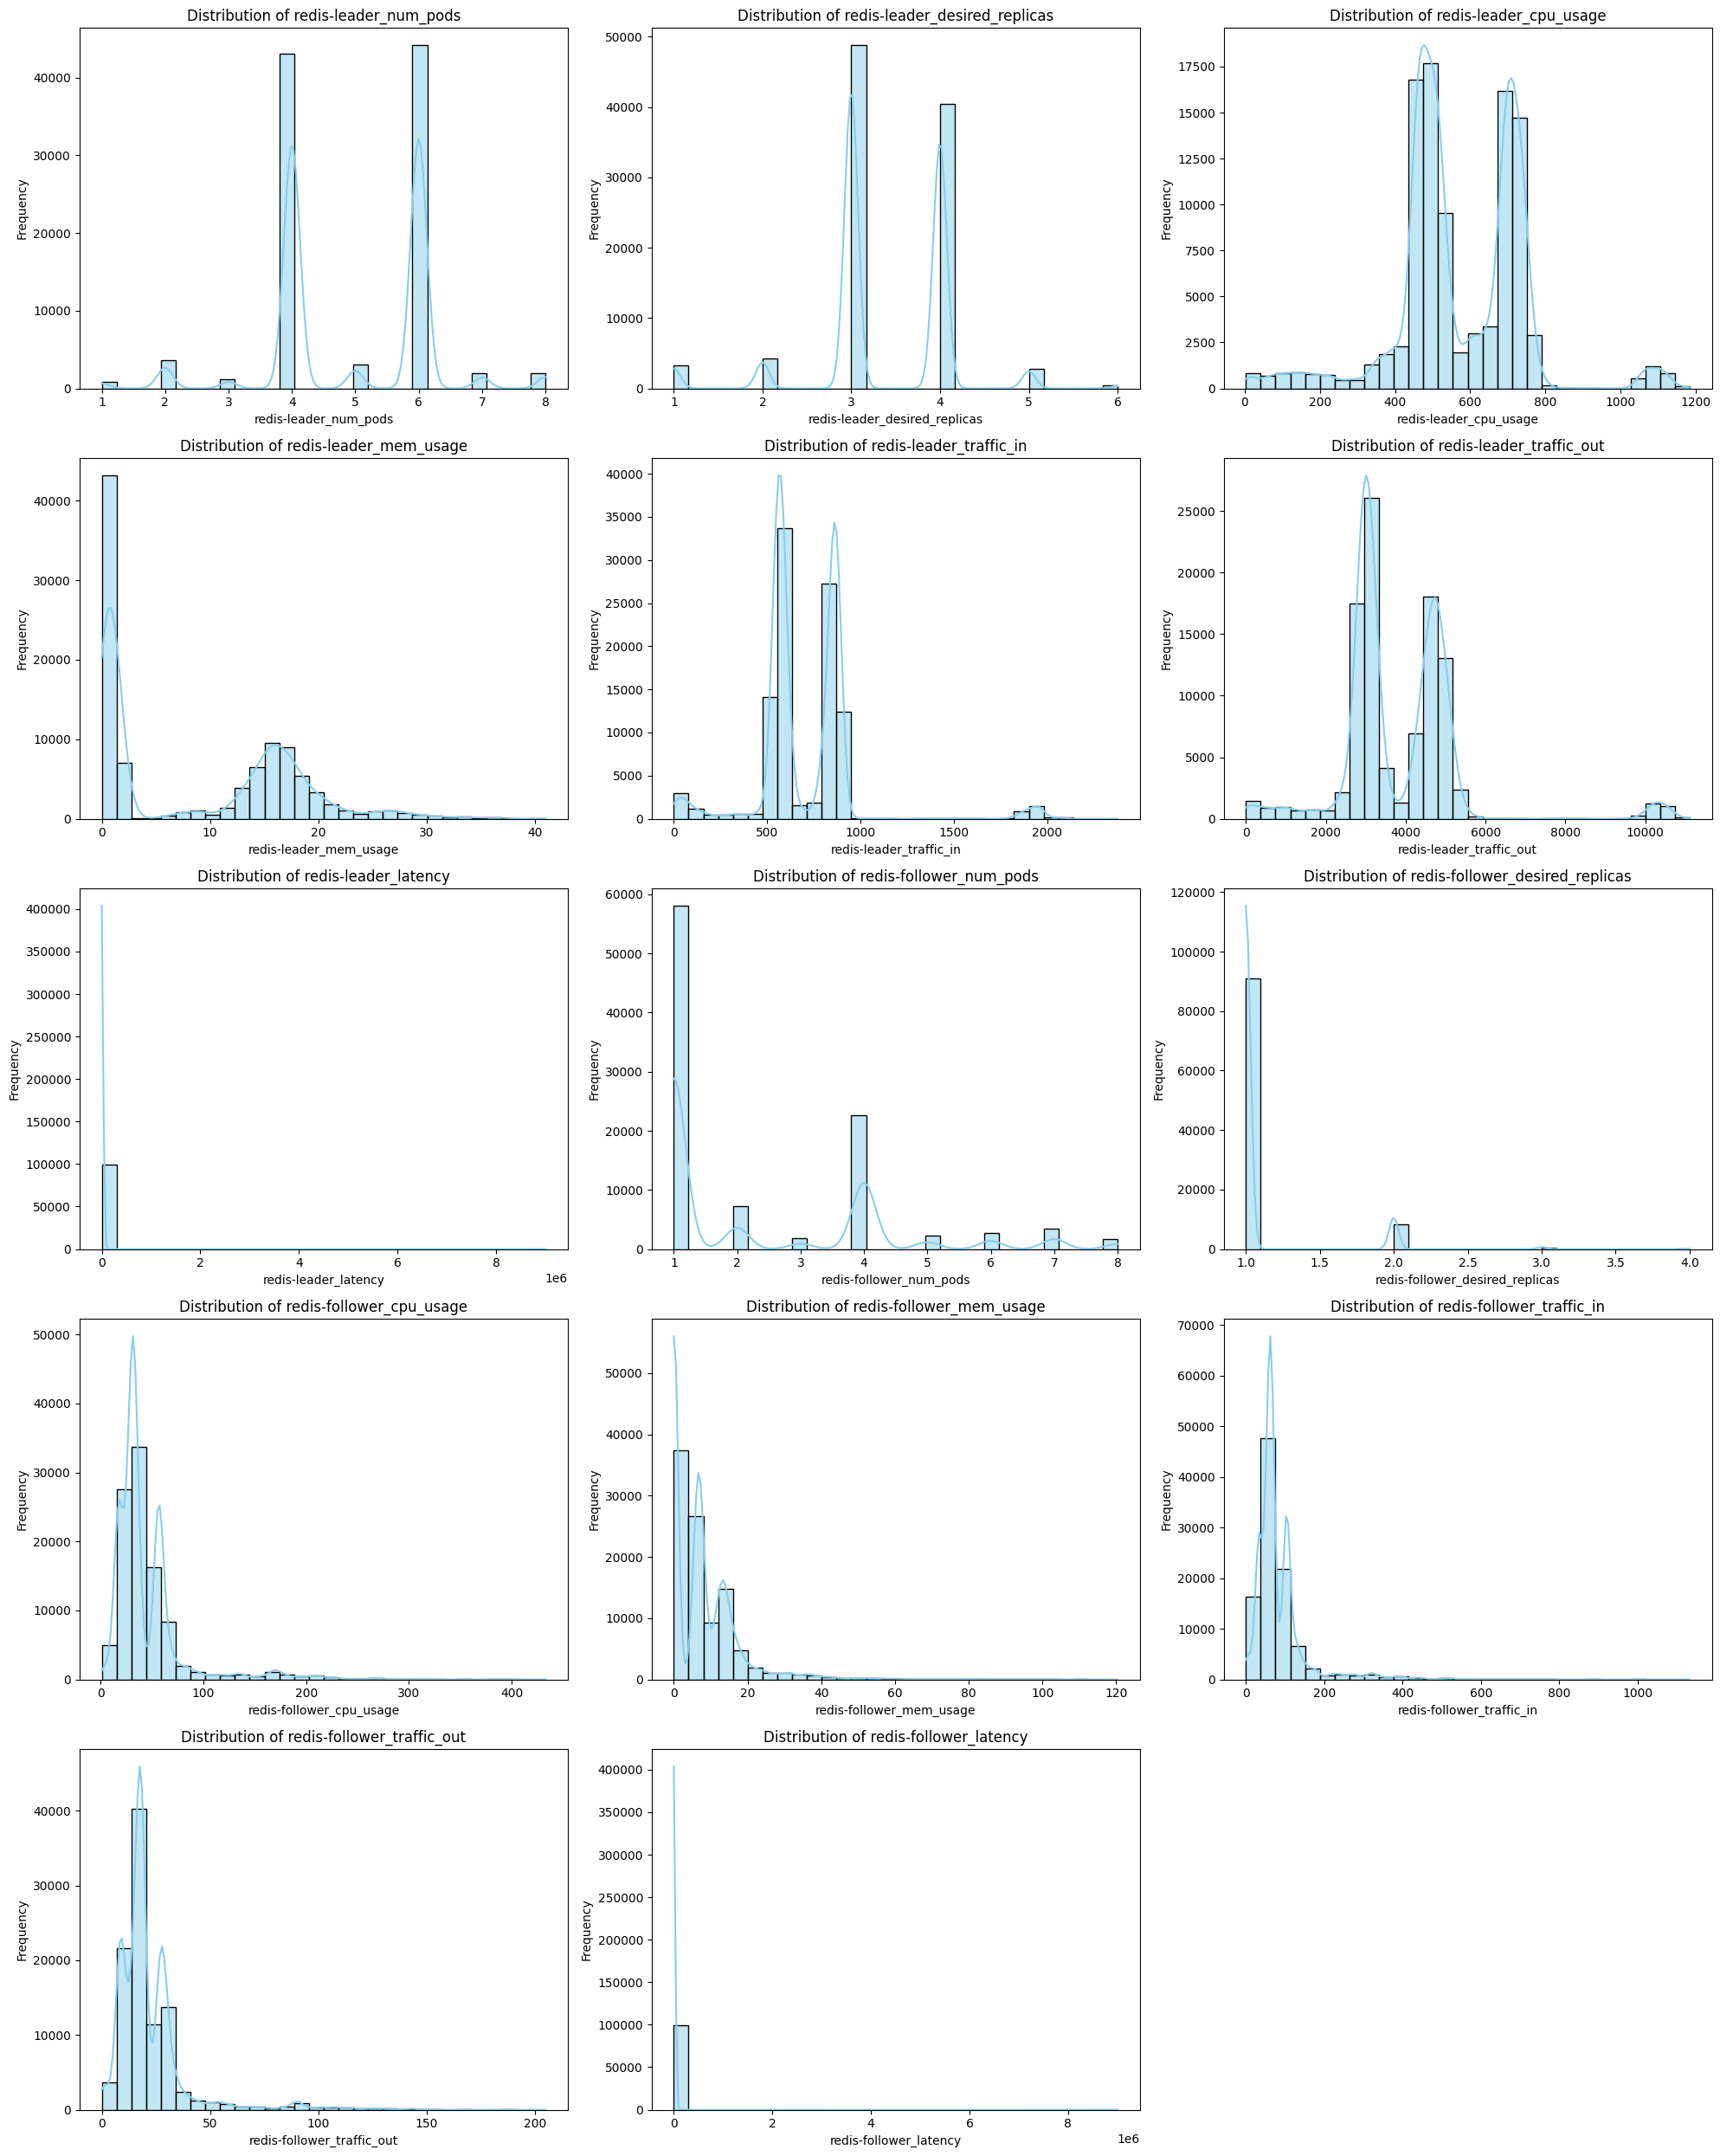

In [215]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

num_cols = 3
num_rows = (len(numerical_cols) + num_cols - 1) // num_cols

plt.figure(figsize=(20, 5 * num_rows))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(num_rows, num_cols, i)
    sns.histplot(df[col], bins=30, kde=True, color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Pod-count combinations

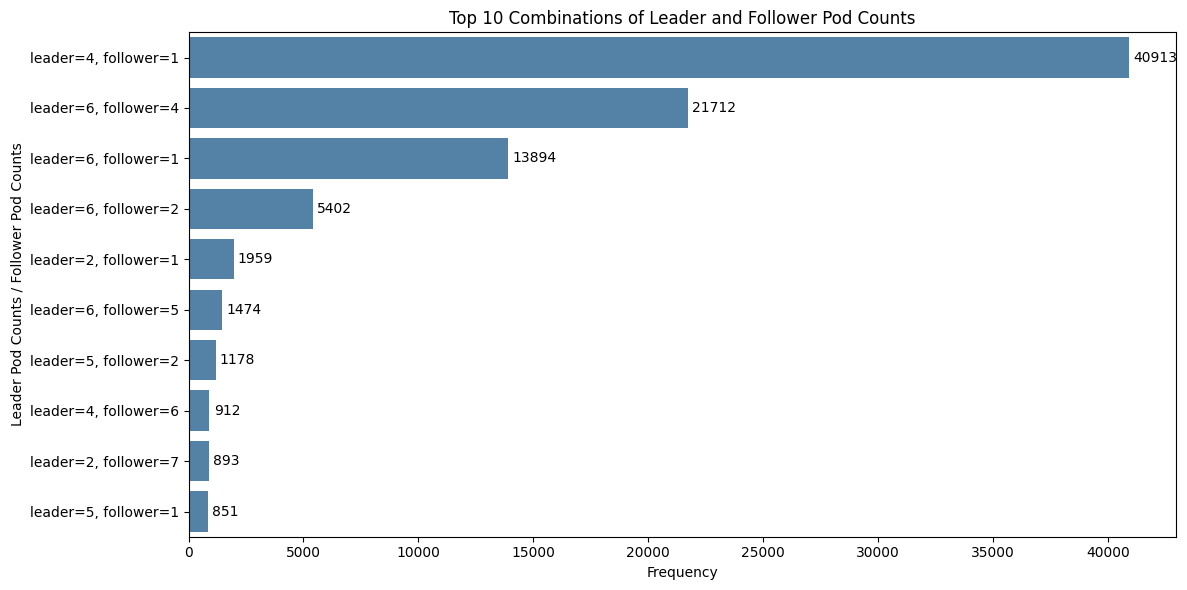

In [216]:
top_n = 10
combinations = df.groupby(["redis-leader_num_pods", "redis-follower_num_pods"]).size().reset_index(name="count")
top_combinations = combinations.sort_values(by="count", ascending=False).head(top_n)

top_combinations["combination"] = "leader=" + top_combinations["redis-leader_num_pods"].astype(int).astype(str) + ", follower=" + top_combinations["redis-follower_num_pods"].astype(int).astype(str)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_combinations, x="count", y="combination", color="steelblue", legend=False)
plt.title(f"Top {top_n} Combinations of Leader and Follower Pod Counts")
plt.xlabel("Frequency")
plt.ylabel("Leader Pod Counts / Follower Pod Counts")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

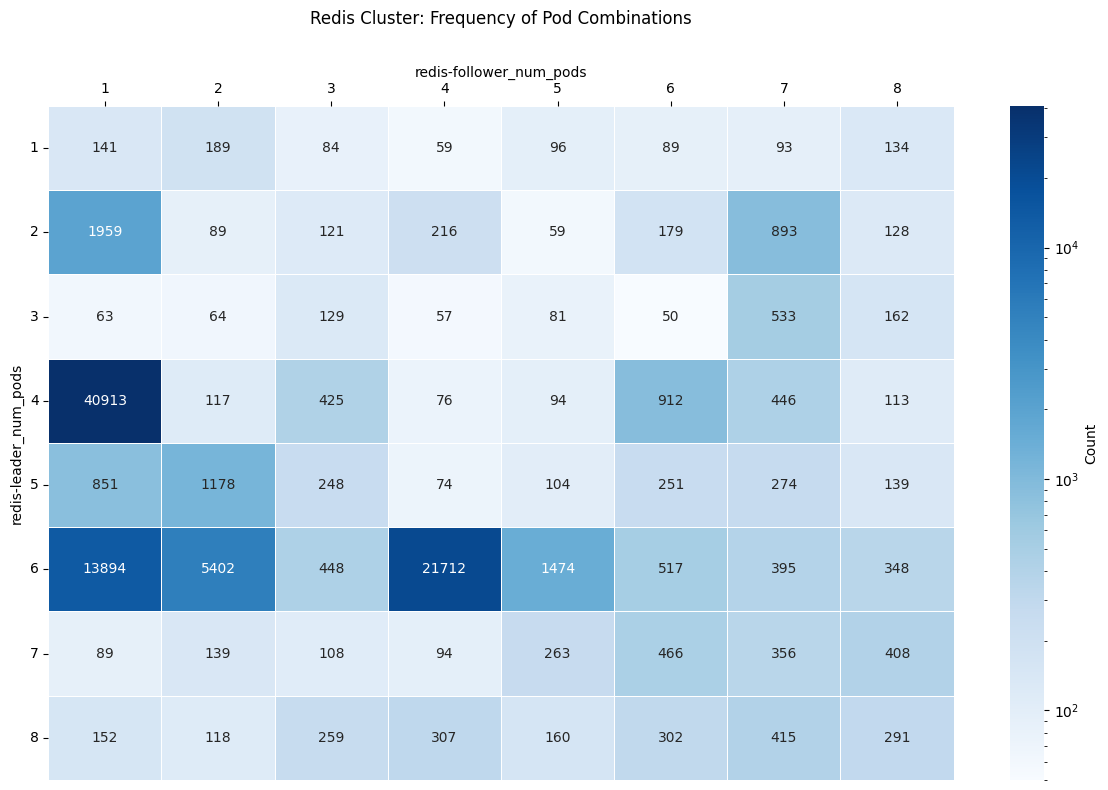

In [217]:
heatmap_data = pd.crosstab(df["redis-leader_num_pods"], df["redis-follower_num_pods"])
heatmap_data = heatmap_data.replace(0, np.nan)

plt.figure(figsize=(12, 8))

ax = sns.heatmap(heatmap_data, annot=True, fmt="g", cmap="Blues", norm=LogNorm(), linewidths=.5, cbar_kws={"label": "Count"})
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

plt.title("Redis Cluster: Frequency of Pod Combinations", pad=30)
plt.ylabel("redis-leader_num_pods")
plt.xlabel("redis-follower_num_pods")

plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### CPU usage vs inbound traffic

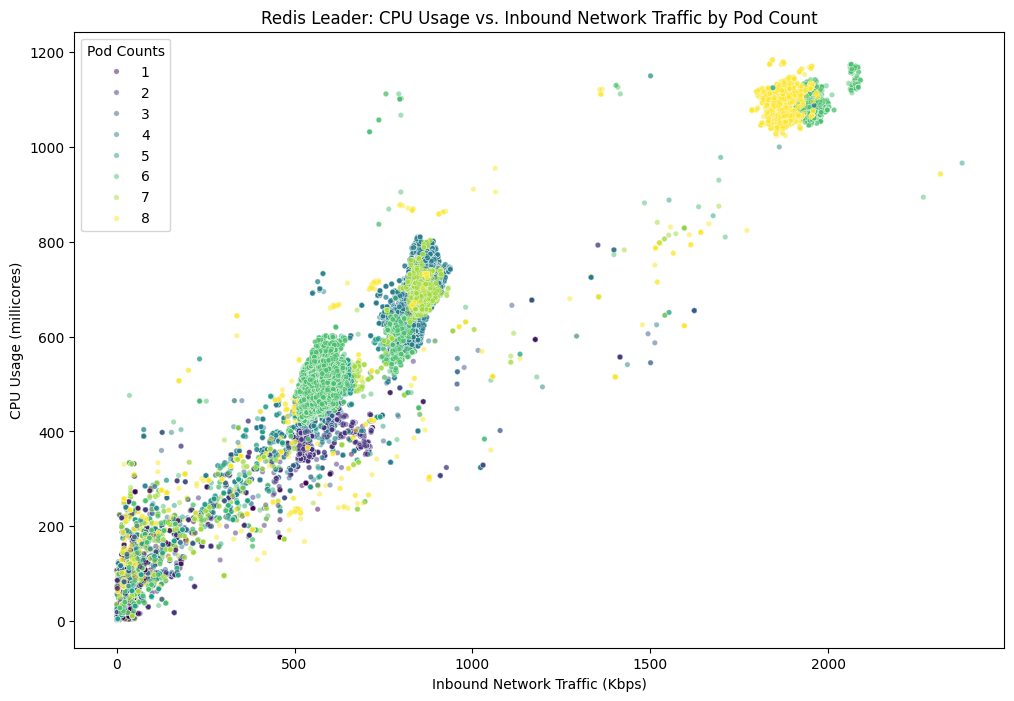

In [218]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x="redis-leader_traffic_in", y="redis-leader_cpu_usage", hue="redis-leader_num_pods", 
                hue_order=sorted(df["redis-leader_num_pods"].unique()), s=15, legend="full", palette="viridis", alpha=0.5)
plt.title("Redis Leader: CPU Usage vs. Inbound Network Traffic by Pod Count")
plt.xlabel("Inbound Network Traffic (Kbps)")
plt.ylabel("CPU Usage (millicores)")
plt.legend(title="Pod Counts")
plt.show()

### Per-metric boxplots

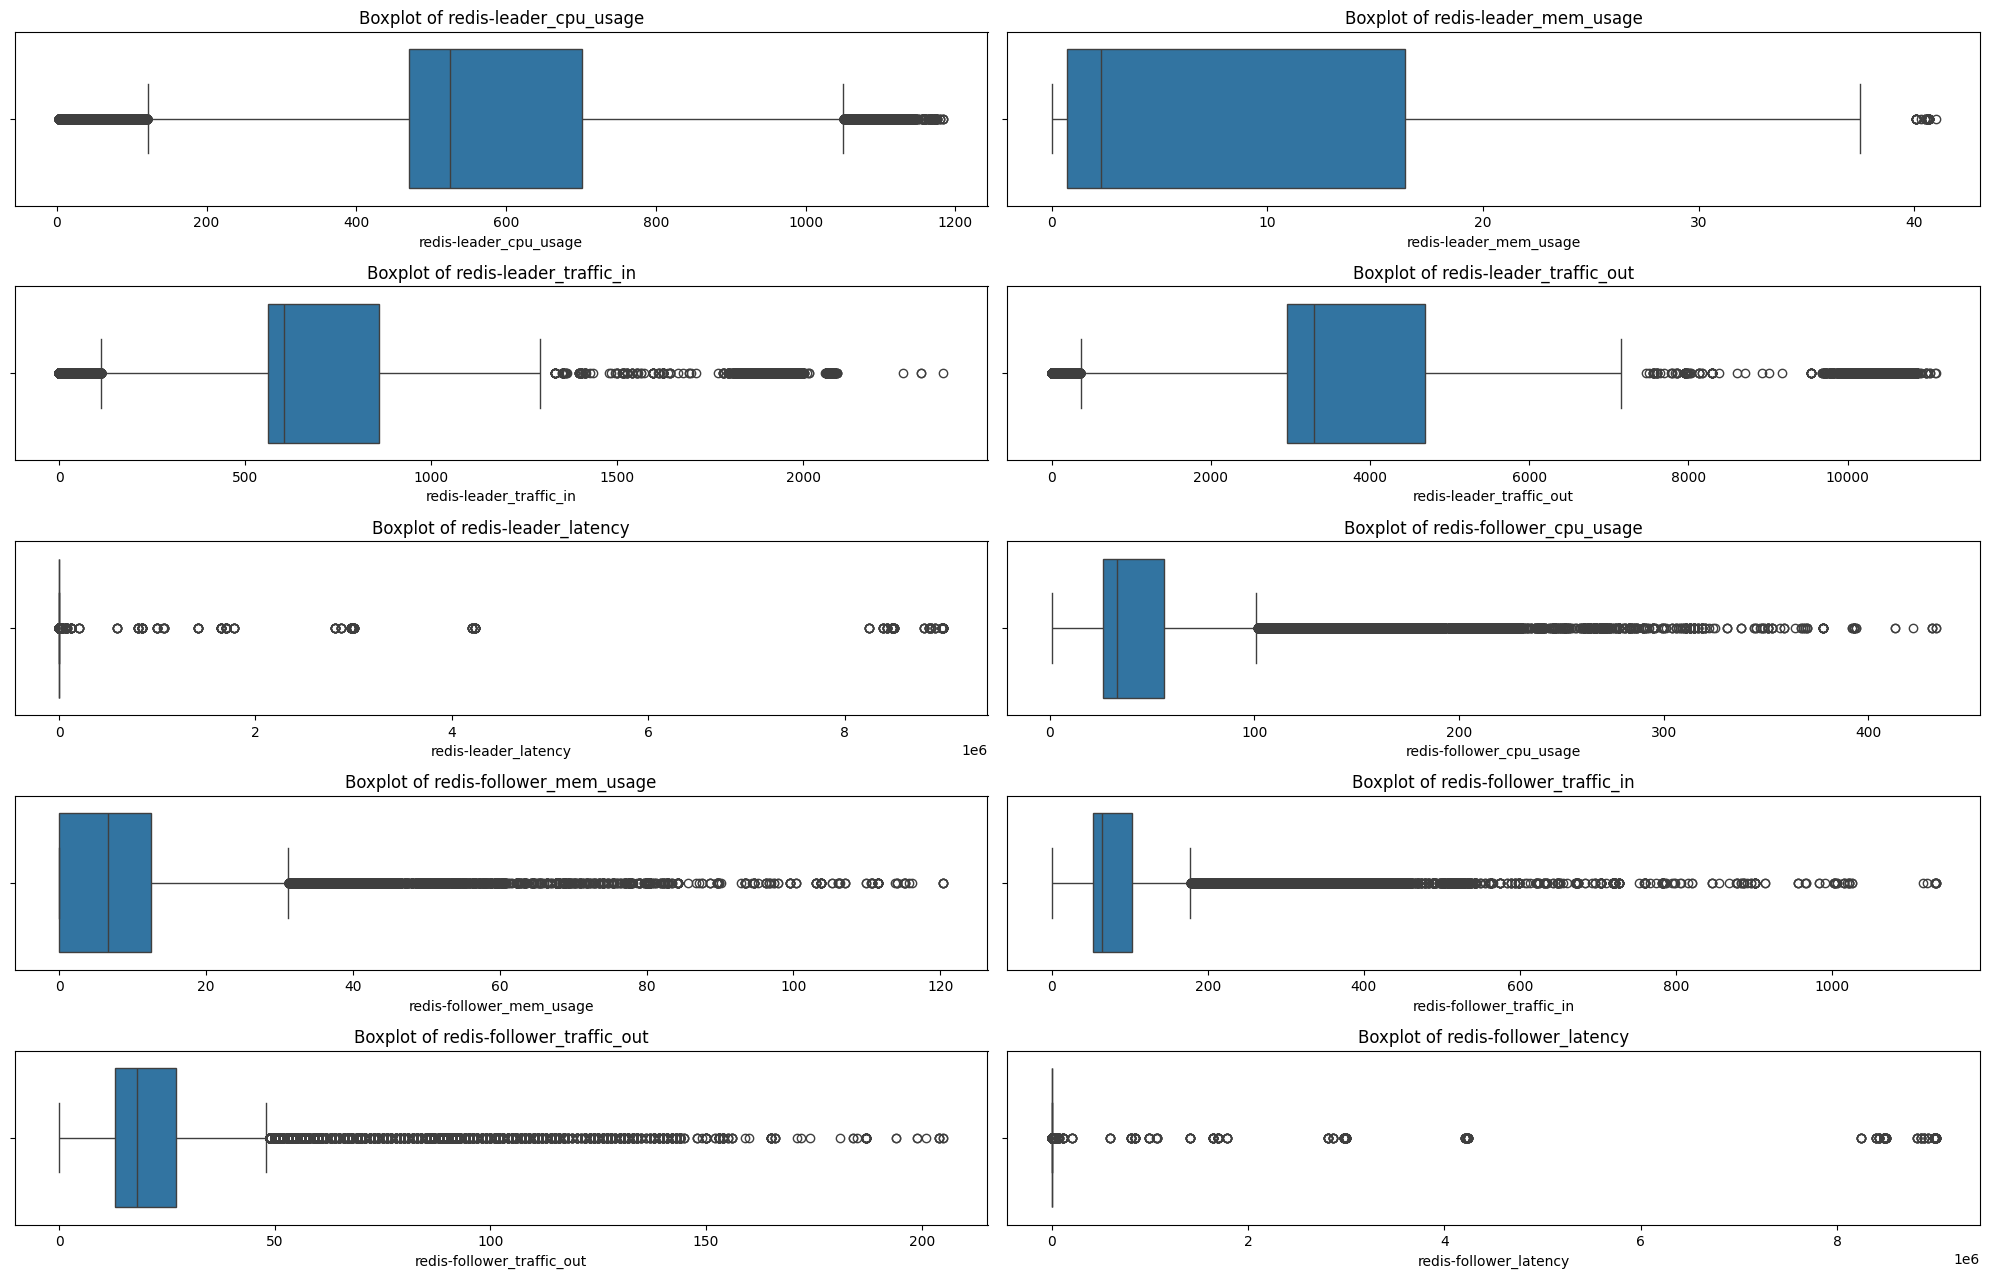

In [219]:
columns_to_plot = [
    "redis-leader_cpu_usage", "redis-leader_mem_usage",
    "redis-leader_traffic_in", "redis-leader_traffic_out",
    "redis-leader_latency",
    "redis-follower_cpu_usage", "redis-follower_mem_usage",
    "redis-follower_traffic_in", "redis-follower_traffic_out",
    "redis-follower_latency"
]

plt.figure(figsize=(20, 15))
for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(6, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

### Correlation matrix

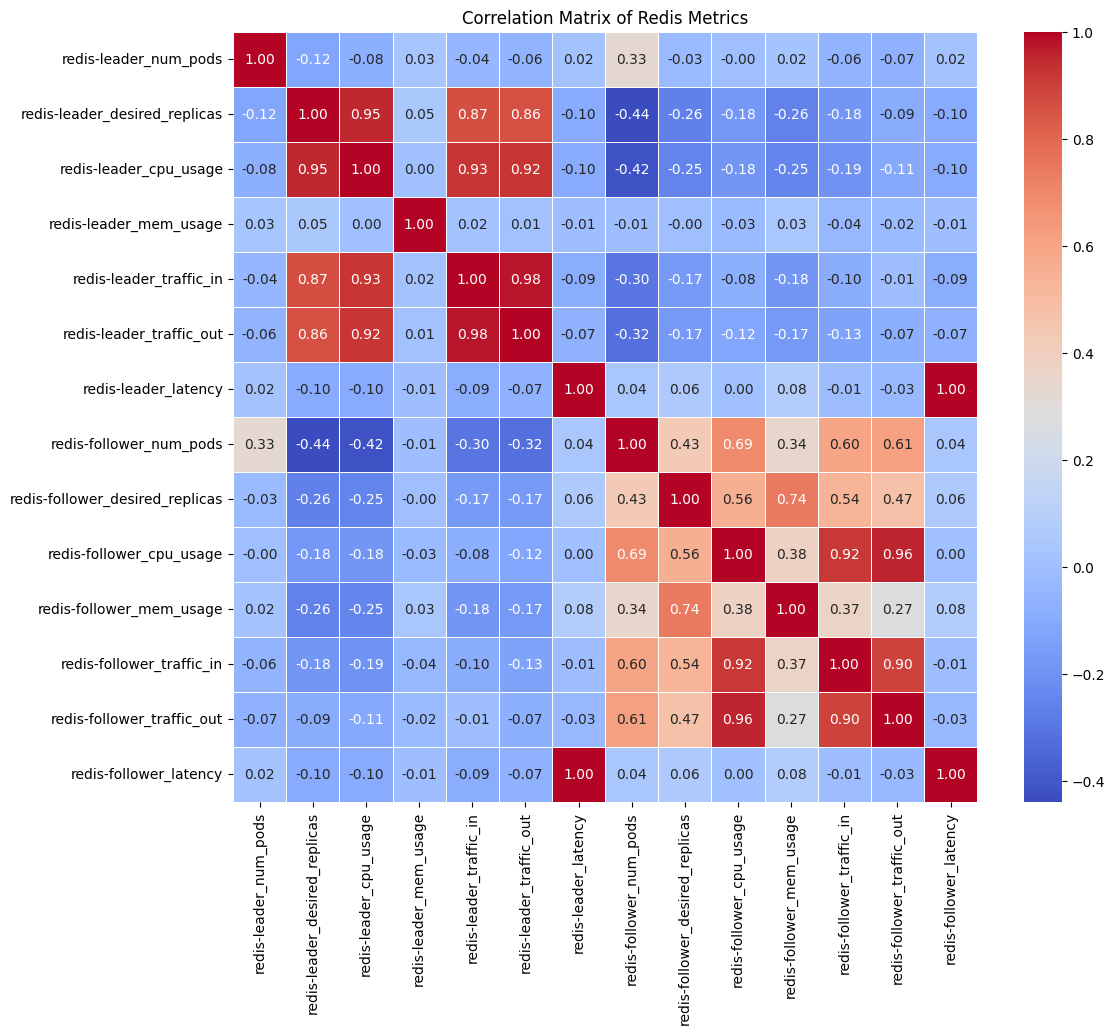

In [220]:
plt.figure(figsize=(12, 10))
corr_matrix = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Redis Metrics")
plt.show()

### Time series - CPU Usage and Inbound Network Traffic over time

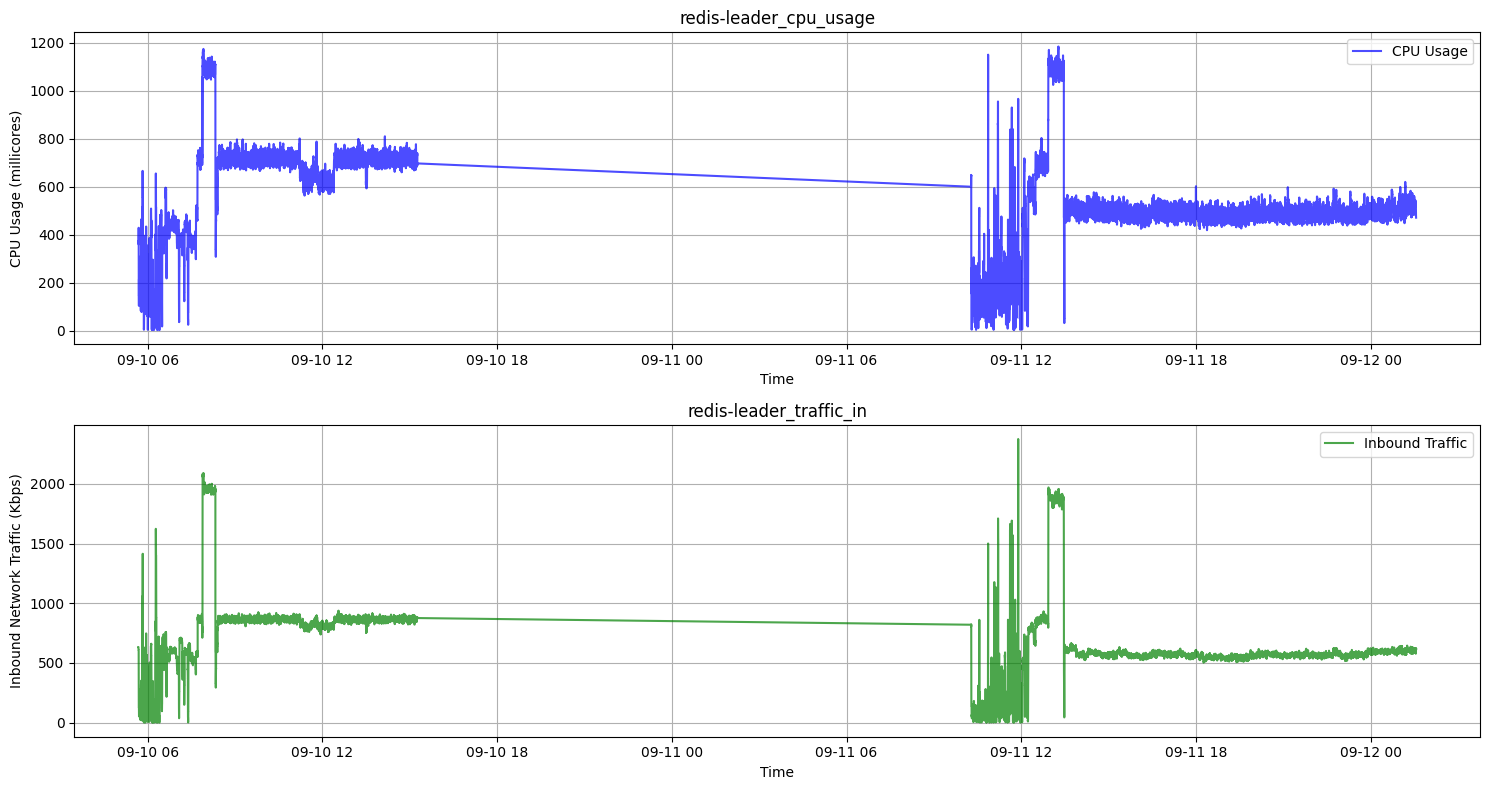

In [221]:
plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
plt.plot(df_time.index, df_time["redis-leader_cpu_usage"], label="CPU Usage", color="blue", alpha=0.7)
plt.title("redis-leader_cpu_usage")
plt.xlabel("Time")
plt.ylabel("CPU Usage (millicores)")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(df_time.index, df_time["redis-leader_traffic_in"], label="Inbound Traffic", color="green", alpha=0.7)
plt.title("redis-leader_traffic_in")
plt.xlabel("Time")
plt.ylabel("Inbound Network Traffic (Kbps)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Inbound Network Traffic vs Outbound Network Traffic

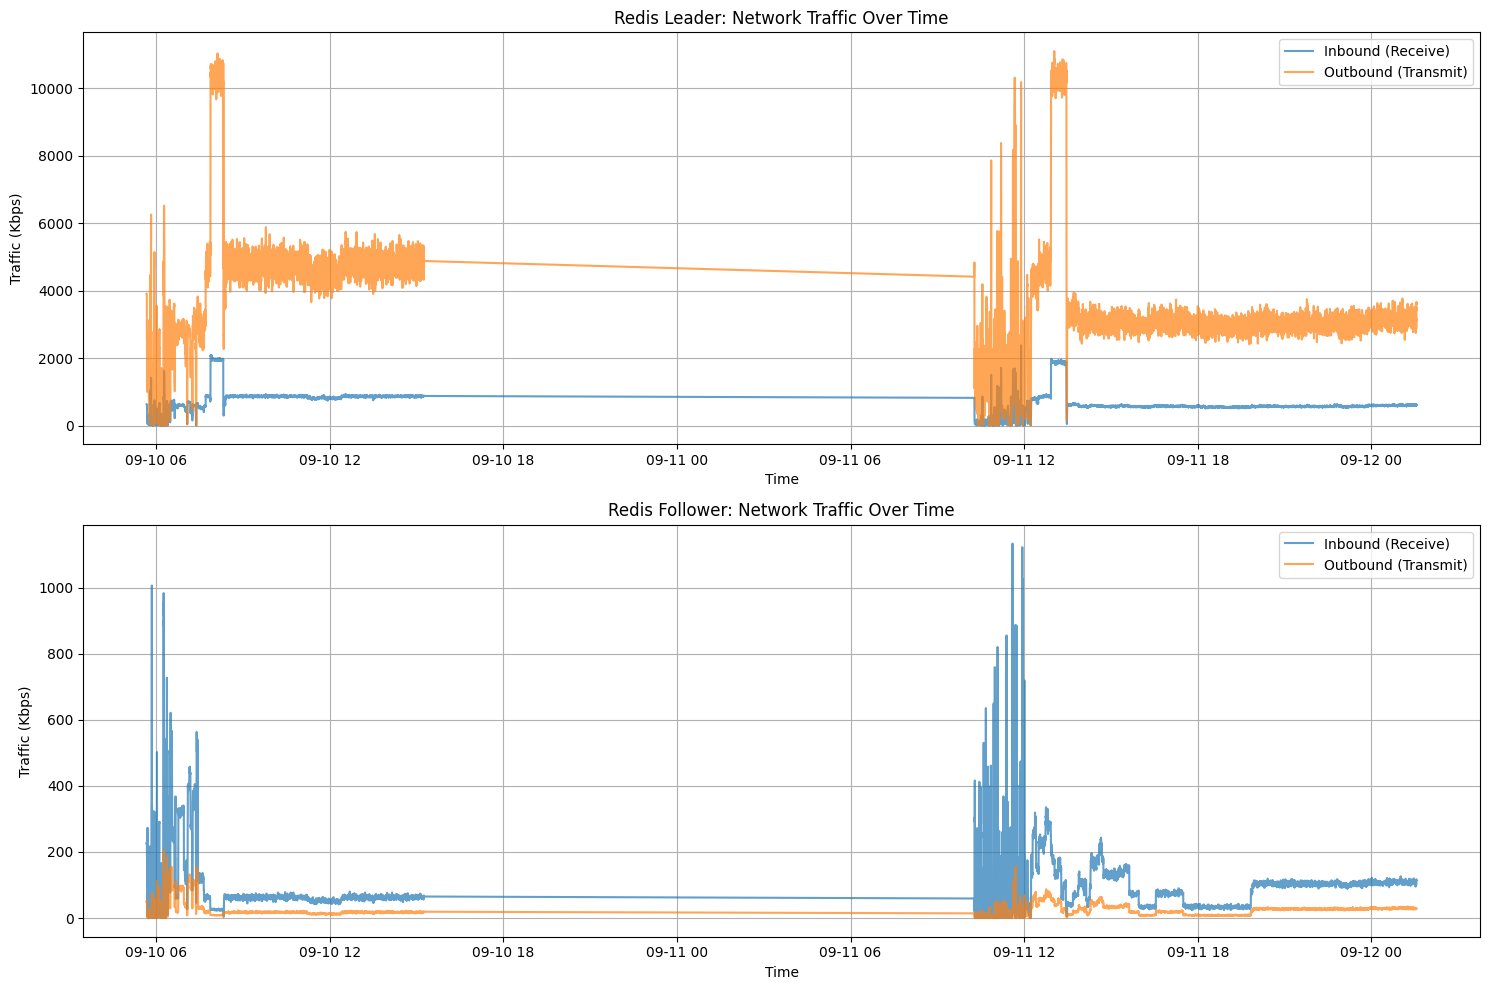

In [222]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(df_time.index, df_time["redis-leader_traffic_in"], label="Inbound (Receive)", color="tab:blue", alpha=0.7)
plt.plot(df_time.index, df_time["redis-leader_traffic_out"], label="Outbound (Transmit)", color="tab:orange", alpha=0.7)
plt.title("Redis Leader: Network Traffic Over Time")
plt.ylabel("Traffic (Kbps)")
plt.xlabel("Time")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(df_time.index, df_time["redis-follower_traffic_in"], label="Inbound (Receive)", color="tab:blue", alpha=0.7)
plt.plot(df_time.index, df_time["redis-follower_traffic_out"], label="Outbound (Transmit)", color="tab:orange", alpha=0.7)
plt.title("Redis Follower: Network Traffic Over Time")
plt.ylabel("Traffic (Kbps)")
plt.xlabel("Time")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Leader Inbound Network Traffic vs Follower Inbound Network Traffic

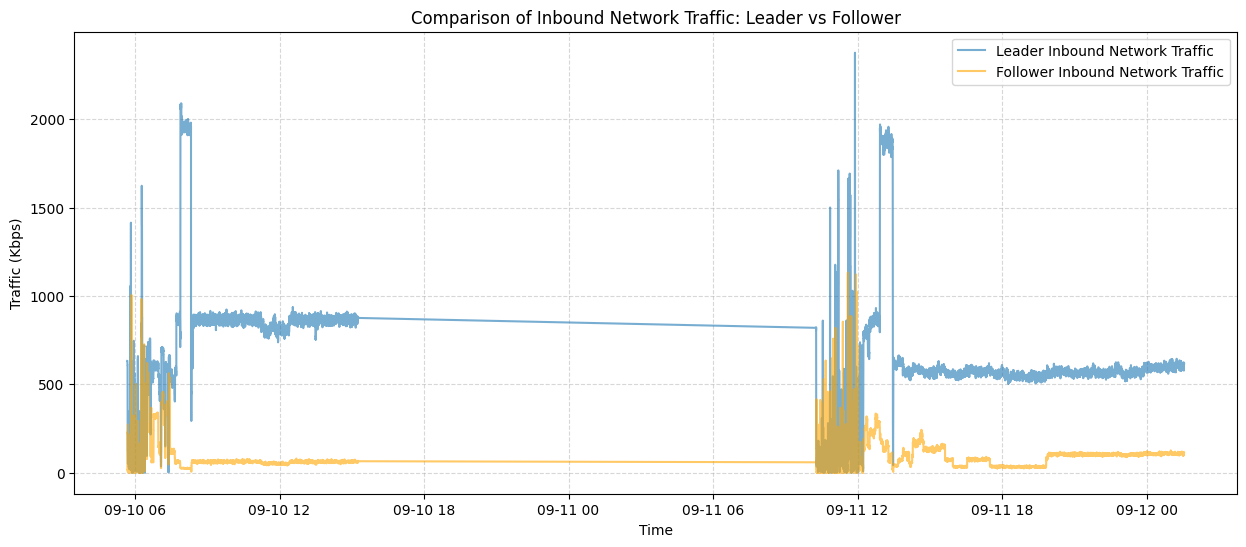

In [223]:
plt.figure(figsize=(15, 6))
plt.plot(df_time.index, df_time["redis-leader_traffic_in"], label="Leader Inbound Network Traffic", alpha=0.6)
plt.plot(df_time.index, df_time["redis-follower_traffic_in"], label="Follower Inbound Network Traffic", alpha=0.6, color="orange")

plt.title("Comparison of Inbound Network Traffic: Leader vs Follower")
plt.xlabel("Time")
plt.ylabel("Traffic (Kbps)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Traffic vs number of pods

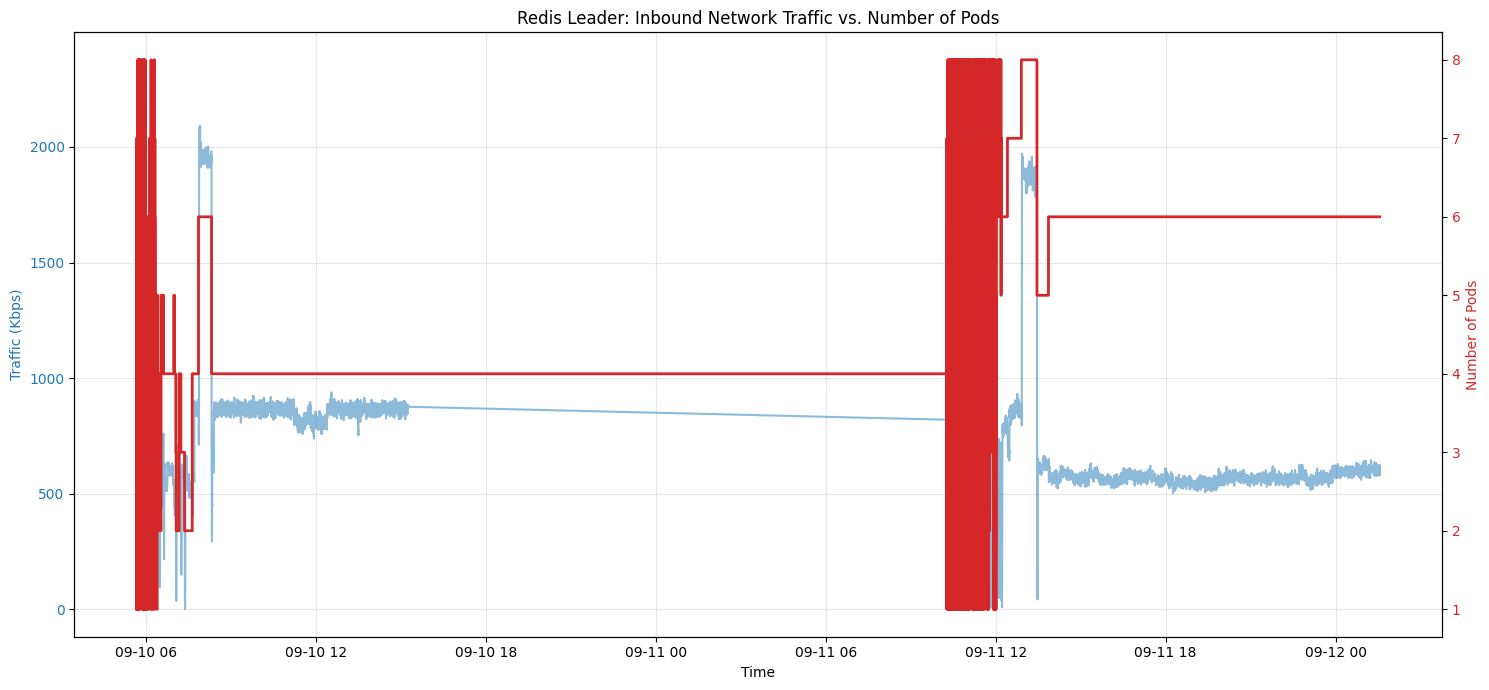

In [224]:
fig, ax1 = plt.subplots(figsize=(15, 7))

color = "tab:blue"
ax1.set_xlabel("Time")
ax1.set_ylabel("Traffic (Kbps)", color=color)
ax1.plot(df_time.index, df_time["redis-leader_traffic_in"], color=color, alpha=0.5, label="Traffic In")
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Number of Pods", color=color)
ax2.step(df_time.index, df_time["redis-leader_num_pods"], color=color, where="post", linewidth=2, label="Leader Pods")
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Redis Leader: Inbound Network Traffic vs. Number of Pods")
fig.tight_layout()
plt.show()

### Latency analysis

Redis latency in this dataset is collected with the Prometheus `irate()` function, which only uses the two most recent samples to estimate the per-second rate.  When a Redis pod restarts, the underlying counter resets, and `irate()` then sees a huge negative delta over a small time window and reports a large value (the cells below show maxima in the millions of seconds, which is physically impossible).

We"ll preserve these spikes in the dataset, because that is the way Redis Cluster is doing in a real k8s cluster.

- A deployed agent on a real cluster will observe these same counter-reset artefacts every time a pod restarts.
- The reward strategy that uses latency (`LatencyStrategy`) already normalises by an SLA threshold and clamps the resulting ratio, so the downstream impact of extreme values is bounded.
- The simulation strategies sample rows uniformly; preserving the spike distribution keeps the empirical latency distribution faithful to the source.

In [225]:
lat = df["redis-leader_latency"]
print(f"Min: {lat.min():.6f}")
print(f"Median: {lat.median():.6f}")
print(f"Mean: {lat.mean():.6f}")
print(f"P95: {lat.quantile(0.95):.6f}")
print(f"P99: {lat.quantile(0.99):.6f}")
print(f"Max: {lat.max():,.2f}")
print(f"Values > 1.0s: {(lat > 1.0).sum():,} ({(lat > 1.0).mean():.2%})")
print(f"Values > 100s: {(lat > 100).sum():,}")
print(f"Values > 10,000s: {(lat > 10_000).sum():,}")

Min: 0.000000
Median: 0.019000
Mean: 12305.271162
P95: 0.425000
P99: 6.974000
Max: 9,004,164.74
Values > 1.0s: 3,707 (3.71%)
Values > 100s: 558
Values > 10,000s: 348


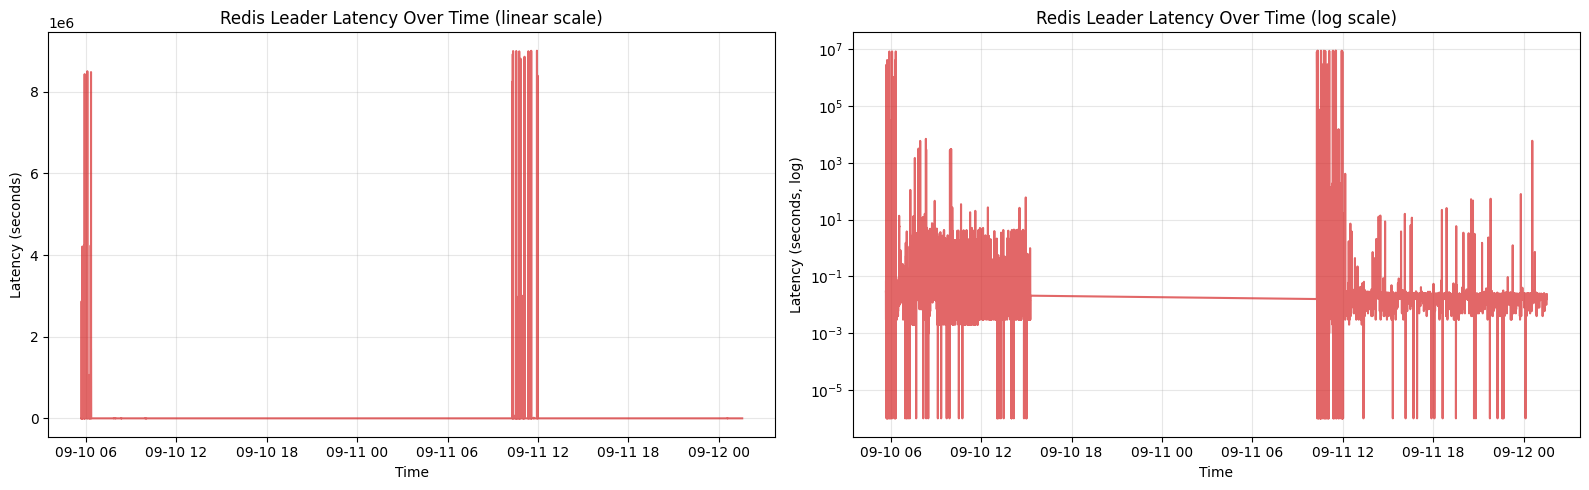

In [226]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df_time.index, df_time["redis-leader_latency"], color="tab:red", alpha=0.7)
axes[0].set_title("Redis Leader Latency Over Time (linear scale)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Latency (seconds)")
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(df_time.index, df_time["redis-leader_latency"].clip(lower=1e-6), color="tab:red", alpha=0.7)
axes[1].set_title("Redis Leader Latency Over Time (log scale)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Latency (seconds, log)")
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

### Gap analysis

Two distinct gap distributions matter:

- **v1 (with duplicates)** - median = 1 s, p99 = 2 s.  Misleading because the 61% duplicate rows are mostly consecutive 1–2 s apart.
- **without duplicates** - median = 2 s, p95 = 6 s, **p99 = 8 s**, p999 = 10 s, max ≈ 13 s (excluding the recording outage).

The decision constants flow from the *post-dedup* numbers:

- `MAX_GAP_SECONDS = 15` — forward-fill any gap up to 15 s.  This is a conservative upper bound that comfortably covers the post-dedup p999 of 10 s (and the observed max of ~12 s).  Setting it ≥ 10 s gives an identical final dataset, since the `MAX_CONSECUTIVE = 3` step below collapses any extra ffilled rows.
- The recording outage (~19 hours) is **not** forward-filled — those rows remain NaN and get dropped, then the two surviving segments are stitched together with a fresh sequential index.

In [227]:
diffs = pd.Series(df_time.index).diff().dt.total_seconds().dropna()

print(f"Total samples: {len(df_time):,}")
print(f"Time-gap statistics (seconds between consecutive samples):")
print(f"Median: {diffs.median():.1f}")
print(f"P95: {diffs.quantile(0.95):.1f}")
print(f"P99: {diffs.quantile(0.99):.1f}")
print(f"Max: {diffs.max():,.0f}")
print(f"Gaps > 1 min: {(diffs > 60).sum()}")
print(f"Gaps > 1 hr: {(diffs > 3600).sum()}")

Total samples: 100,000
Time-gap statistics (seconds between consecutive samples):
Median: 1.0
P95: 2.0
P99: 2.0
Max: 68,434
Gaps > 1 min: 1
Gaps > 1 hr: 1


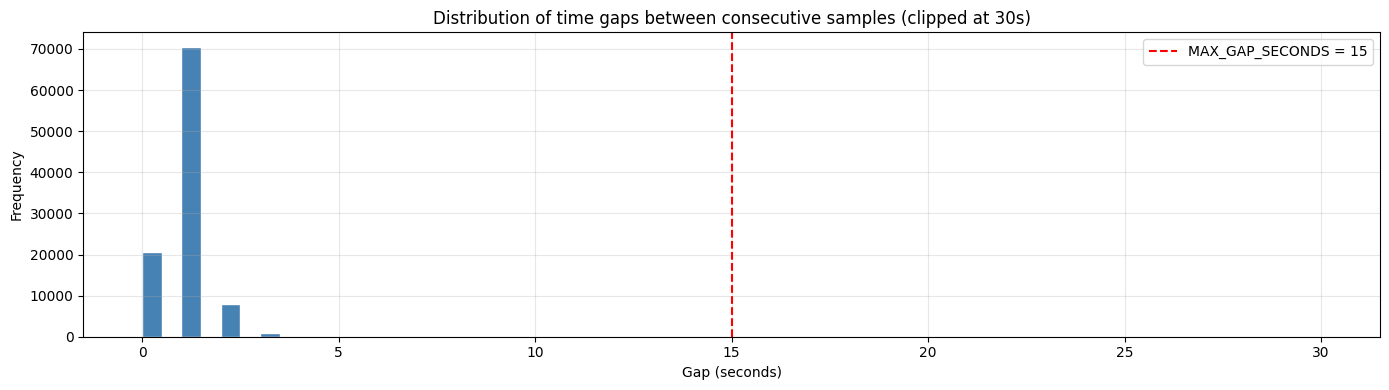

In [228]:
plt.figure(figsize=(14, 4))
plt.hist(diffs.clip(upper=30), bins=60, color="steelblue", edgecolor="white")
plt.axvline(15, color="red", linestyle="--", label="MAX_GAP_SECONDS = 15")
plt.title("Distribution of time gaps between consecutive samples (clipped at 30s)")
plt.xlabel("Gap (seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [229]:
df_dedup = df.drop_duplicates().drop_duplicates(subset=df.columns.drop("date"))
df_dedup = df_dedup.sort_values("date")
diffs_dd = df_dedup["date"].diff().dt.total_seconds().dropna()

print("Gap statistics AFTER value-dedup (input to the resample step):")
print(f"Rows: {len(df_dedup):,}")
print(f"Median: {diffs_dd.median():.1f}s")
print(f"P95: {diffs_dd.quantile(0.95):.1f}s")
print(f"P99: {diffs_dd.quantile(0.99):.1f}s")
print(f"P999: {diffs_dd.quantile(0.999):.1f}s")
print(f"Max (excluding outage): {diffs_dd[diffs_dd < 3600].max():.1f}s")
print(f"Max: {diffs_dd.max():,.0f}s")

Gap statistics AFTER value-dedup (input to the resample step):
Rows: 38,823
Median: 2.0s
P95: 6.0s
P99: 8.0s
P999: 10.0s
Max (excluding outage): 13.0s
Max: 68,440s


## Preprocessing

| Constant | Value | Rationale |
|---|---|---|
| `MAX_GAP_SECONDS` | 15 | Forward-fill any gap up to 15 s.  Post-dedup p999 is 10 s and max real gap is ~13 s, so 15 s is a comfortable upper bound. |
| `MAX_CONSECUTIVE` | 3 | Keep at most 3 consecutive rows with identical metric values (this value was the one used as a waiting period) longer runs are pure scrape-frequency artefacts and don"t add information.  This step also makes the final row count insensitive to `MAX_GAP_SECONDS` for any value ≥ 10 s. |

In [230]:
MAX_GAP_SECONDS = 15
MAX_CONSECUTIVE = 3
OUT_CSV = "../v2/redis_gym_observation.csv"

df_raw = pd.read_csv("redis_gym_observation.csv", parse_dates=["date"])
print(f"Loaded v1: {len(df_raw):,} rows")

Loaded v1: 100,000 rows


### Drop exact-row duplicates

In [231]:
before = len(df_raw)
df1 = df_raw.drop_duplicates()
print(f"{before:,} -> {len(df1):,} rows (removed {before - len(df1):,})")

100,000 -> 85,244 rows (removed 14,756)


### Drop value-duplicates (ignoring date column)

Same metric snapshot recorded at different timestamps — Prometheus re-scraped the same underlying state.  Keep one representative per unique state.

In [232]:
before = len(df1)
df2 = df1.drop_duplicates(subset=df1.columns.drop("date"))
print(f"{before:,} -> {len(df2):,} rows (removed {before - len(df2):,})")

85,244 -> 38,823 rows (removed 46,421)


### Resolve timestamp conflicts

Multiple rows sharing the same second are collapsed to their per-column median.

In [233]:
dup_count = df2.duplicated(subset=["date"]).sum()
if dup_count == 0:
    df3 = df2.copy()
    print("No timestamp conflicts.")
else:
    print(f"Resolving {dup_count:,} timestamp conflicts")
    numeric_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
    df3 = df2.groupby("date")[numeric_cols].median().reset_index()
print(f"-> {len(df3):,} unique timestamps")

Resolving 2,121 timestamp conflicts
-> 36,702 unique timestamps


### Sort and set DatetimeIndex

In [234]:
df4 = df3.sort_values("date").reset_index(drop=True).set_index("date")
df4.index = pd.DatetimeIndex(df4.index)
print(f"{df4.index.min()} -> {df4.index.max()}")

2022-09-10 05:40:37 -> 2022-09-12 01:33:21


### Resample to a dense 1-second grid

Forward-fill at most `MAX_GAP_SECONDS = 15` consecutive seconds.  The 19-hour outage gap will be left as NaN.

In [235]:
full_range = pd.date_range(df4.index.min(), df4.index.max(), freq="1s")
print(f"Dense grid: {len(full_range):,} seconds")
df5 = df4.reindex(full_range).ffill(limit=MAX_GAP_SECONDS)
n_nan = int(df5.isna().any(axis=1).sum())
print(f"NaN rows after ffill(limit={MAX_GAP_SECONDS}): {n_nan:,} (outage gap)")

Dense grid: 157,965 seconds
NaN rows after ffill(limit=15): 68,424 (outage gap)


### Drop the outage NaN rows

In [236]:
before = len(df5)
df6 = df5.dropna()
print(f"{before:,} -> {len(df6):,} rows (removed {before - len(df6):,})")

157,965 -> 89,541 rows (removed 68,424)


### Limit consecutive identical-metric runs to `MAX_CONSECUTIVE` (3)

After resampling and forward-filling, long runs of identical rows accumulate during low-traffic periods.  These rows offer no transition information for the agent and bias the experience distribution.  We keep at most 3 consecutive identical-metric rows.

In [237]:
metric_cols = df6.columns.tolist()
changed = (df6[metric_cols] != df6[metric_cols].shift()).any(axis=1)
changed.iloc[0] = True
group_id = changed.cumsum()
rank = df6.groupby(group_id).cumcount()
before = len(df6)
df7 = df6[rank < MAX_CONSECUTIVE]
print(f"{before:,} -> {len(df7):,} rows (removed {before - len(df7):,} repeated states)")

89,541 -> 69,013 rows (removed 20,528 repeated states)


### Reindex with 1-second timestamps

This stitches the two surviving segments together and presents the output as a single unbroken recording starting from the original timestamp.

In [238]:
START = pd.Timestamp("2022-09-10 05:40:37")
df8 = df7.copy()
df8.index = pd.date_range(start=START, periods=len(df8), freq="1s")
df8.index.name = "date"
print(f"Reindexed: {df8.index[0]} -> {df8.index[-1]}")

Reindexed: 2022-09-10 05:40:37 -> 2022-09-11 00:50:49


### Save the new v2 dataset

In [239]:
out_path = Path(OUT_CSV)
out_path.parent.mkdir(parents=True, exist_ok=True)
df_out = df8.reset_index()
df_out.to_csv(out_path, index=False)
print(f"Saved {out_path} ({len(df_out):,} rows)")

Saved ../v2/redis_gym_observation.csv (69,013 rows)


In [240]:
diffs= pd.Series(df8.index).diff().dt.total_seconds().dropna()
dup_idx = df8.index.duplicated().sum()
dup_rows = df8.duplicated().sum()

print("Validation:")
print(f"Rows: {len(df8):,}")
print(f"Duplicate timestamps: {dup_idx}")
print(f"Duplicate rows: {dup_rows}")
print(f"Max time gap (s): {diffs.max():.0f}")
print(f"Latency max (leader): {df8["redis-leader_latency"].max():,.2f}")
print(f"Any NaN cell: {df8.isna().any().any()}")

Validation:
Rows: 69,013
Duplicate timestamps: 0
Duplicate rows: 32311
Max time gap (s): 1
Latency max (leader): 9,004,164.74
Any NaN cell: False


## Exploratory Data Analysis (after preprocessing)

This section re-runs the most informative analyses on the **v2** dataset and shows them side-by-side with the **v1**.  The goal is to validate that the pipeline:

- Removes the duplicates that biased the experience distribution
- Stitches the recording into a continuous 1-second time series
- Doesn"t lose information about the pod-count combinations the cluster actually visited

### Row-count and duplicate comparison

In [241]:
v1_for_compare = df_raw
v2_for_compare = df8.reset_index()

val_cols_v1 = v1_for_compare.columns.drop("date")
val_cols_v2 = v2_for_compare.columns.drop("date")

summary = pd.DataFrame({
    "v1": [len(v1_for_compare),
           v1_for_compare.duplicated().sum(),
           v1_for_compare.duplicated(subset=val_cols_v1).sum()],
    "v2": [len(v2_for_compare),
           v2_for_compare.duplicated().sum(),
           v2_for_compare.duplicated(subset=val_cols_v2).sum()],
}, index=["Total rows",
          "Exact-row duplicates (including date)",
          "Value duplicates (ignoring date)"])
print(summary)

                                           v1     v2
Total rows                             100000  69013
Exact-row duplicates (including date)   14756      0
Value duplicates (ignoring date)        61177  32311


### Latency distribution — v1 vs v2

              v1            v2
p50        0.019  1.900000e-02
p95        0.425  4.994000e-01
p99        6.974  4.924680e+02
max  9004164.740  9.004165e+06


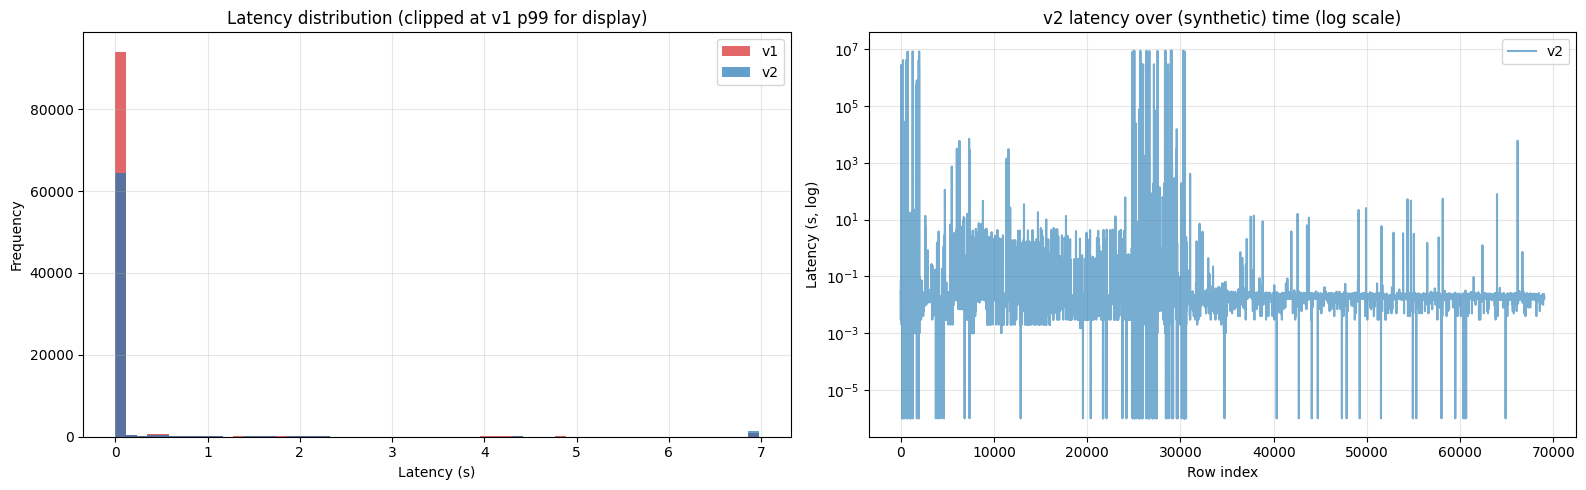

In [242]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

raw_lat = df_raw["redis-leader_latency"]
cleaned_lat = df8["redis-leader_latency"]

stats = pd.DataFrame({
    "v1": [raw_lat.median(), raw_lat.quantile(0.95), raw_lat.quantile(0.99), raw_lat.max()],
    "v2": [cleaned_lat.median(), cleaned_lat.quantile(0.95), cleaned_lat.quantile(0.99), cleaned_lat.max()],
}, index=["p50", "p95", "p99", "max"])
print(stats)

axes[0].hist(raw_lat.clip(upper=raw_lat.quantile(0.99)), bins=60, color="tab:red", alpha=0.7, label="v1")
axes[0].hist(cleaned_lat.clip(upper=raw_lat.quantile(0.99)), bins=60, color="tab:blue", alpha=0.7, label="v2")
axes[0].set_title("Latency distribution (clipped at v1 p99 for display)")
axes[0].set_xlabel("Latency (s)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(np.arange(len(cleaned_lat)), cleaned_lat.clip(lower=1e-6).values, alpha=0.6, color="tab:blue", label="v2")
axes[1].set_title("v2 latency over (synthetic) time (log scale)")
axes[1].set_xlabel("Row index")
axes[1].set_ylabel("Latency (s, log)")
axes[1].legend()
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

### Time-gap continuity

In [243]:
raw_diffs = pd.Series(df_raw["date"]).sort_values().diff().dt.total_seconds().dropna()
cleaned_diffs = pd.Series(df8.index).diff().dt.total_seconds().dropna()

print(f"v1 - max gap: {raw_diffs.max():,.0f}s | unique gaps: {raw_diffs.nunique()}")
print(f"v2 - max gap: {cleaned_diffs.max():,.0f}s | unique gaps: {cleaned_diffs.nunique()}")

v1 - max gap: 68,434s | unique gaps: 7
v2 - max gap: 1s | unique gaps: 1


### Pod-count combination coverage - v2 dataset

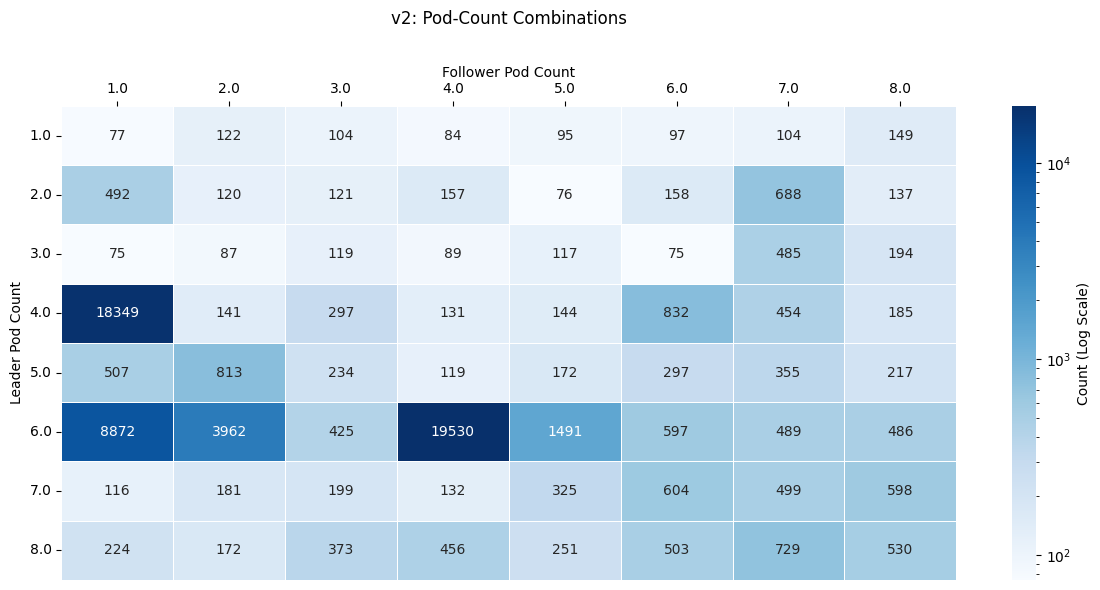

In [244]:
heatmap_data_v2 = pd.crosstab(df8["redis-leader_num_pods"], df8["redis-follower_num_pods"])
heatmap_data_v2 = heatmap_data_v2.replace(0, np.nan)

plt.figure(figsize=(12, 6))
ax = sns.heatmap(heatmap_data_v2, annot=True, fmt="g", cmap="Blues", norm=LogNorm(), linewidths=.5, cbar_kws={"label": "Count (Log Scale)"})
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
plt.title("v2: Pod-Count Combinations", pad=30)
plt.ylabel("Leader Pod Count")
plt.xlabel("Follower Pod Count")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Per-metric distribution — v1 vs v2

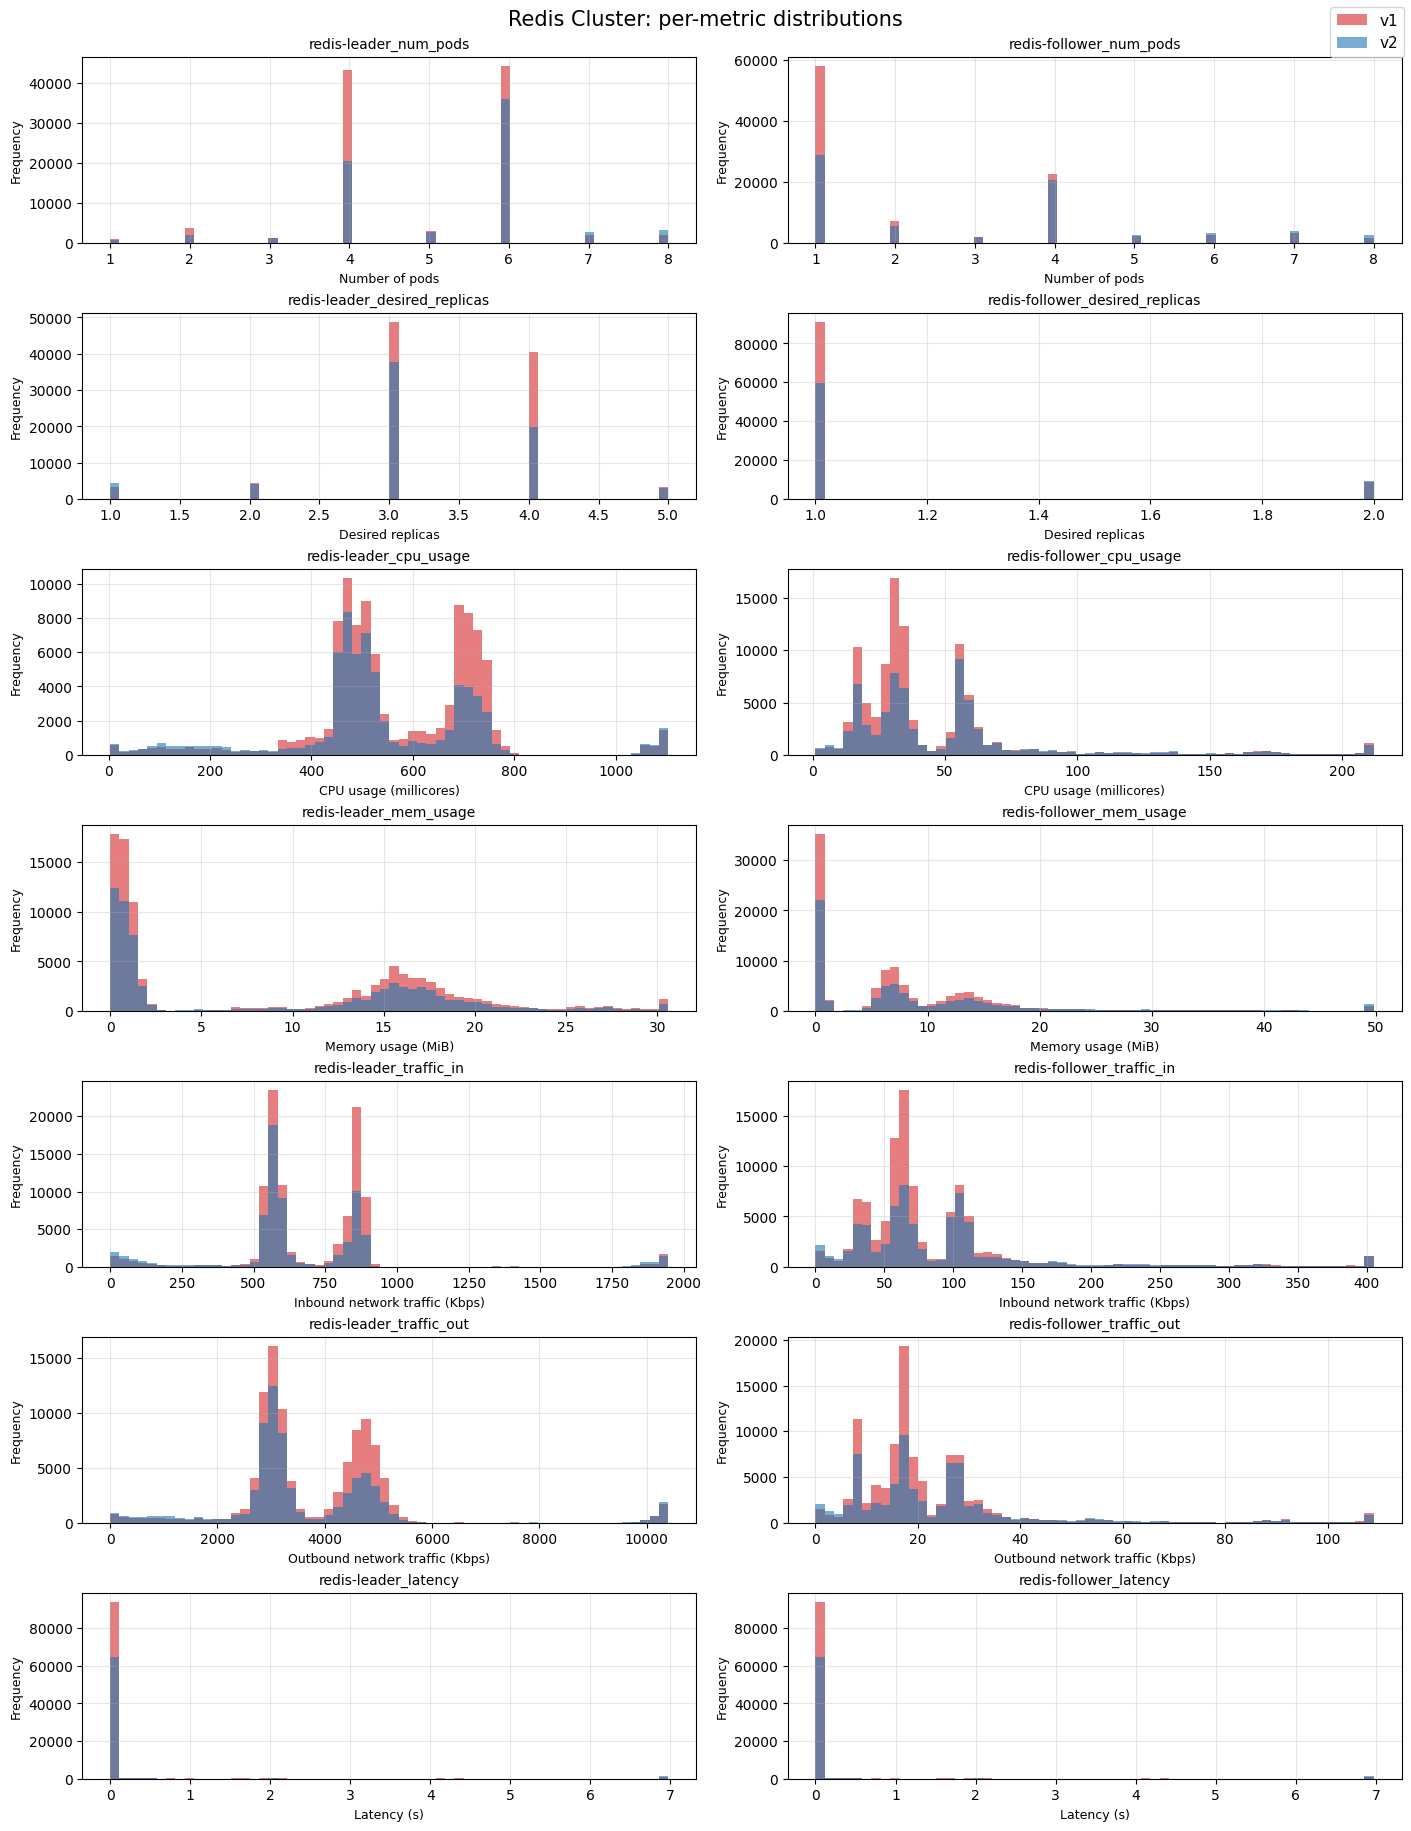

In [245]:
metrics = [
    ("num_pods", "Number of pods"),
    ("desired_replicas", "Desired replicas"),
    ("cpu_usage", "CPU usage (millicores)"),
    ("mem_usage", "Memory usage (MiB)"),
    ("traffic_in", "Inbound network traffic (Kbps)"),
    ("traffic_out", "Outbound network traffic (Kbps)"),
    ("latency", "Latency (s)"),
]
services = ["redis-leader", "redis-follower"]

nrows = len(metrics)
ncols = len(services)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(7 * ncols, 2.6 * nrows),
                         layout="constrained")

for r, (suffix, xlabel) in enumerate(metrics):
    for c, service in enumerate(services):
        ax = axes[r, c]
        col = f"{service}_{suffix}"
        if col in df_raw.columns:
            upper = df_raw[col].quantile(0.99)
            ax.hist(df_raw[col].clip(upper=upper), bins=60,
                    color="tab:red",  alpha=0.6, label="v1")
            ax.hist(df8[col].clip(upper=upper), bins=60,
                    color="tab:blue", alpha=0.6, label="v2")
        ax.set_title(col, fontsize=10)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel("Frequency", fontsize=9)
        ax.grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=11)

fig.suptitle("Redis Cluster: per-metric distributions", fontsize=15)
plt.show()
